In [2]:
import os
os.chdir("//home//rydpi5")

import sympy
from sympy import symbols, sin, cos, Add
from sympy import Matrix, nsolve, nsimplify
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens

# Tabletop test setup

In [1]:
#through the model we document what is the most sensitive parameter
#we simplify the problem by assuming that the two planes share the same values

#-----------------------------------------------------
#plane 1
#-----------------------------------------------------
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.35
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=5e-4
Cav_pos_1=0

MOT_pos_2=5e-4
Cav_pos_2=0

MOT_pos_rel = 0.2
MOT_Cav_dist = -0.044

params_1={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos': MOT_pos_1, 'Cav_pos': Cav_pos_1}
params_2={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos': MOT_pos_2, 'Cav_pos': Cav_pos_2}

reference


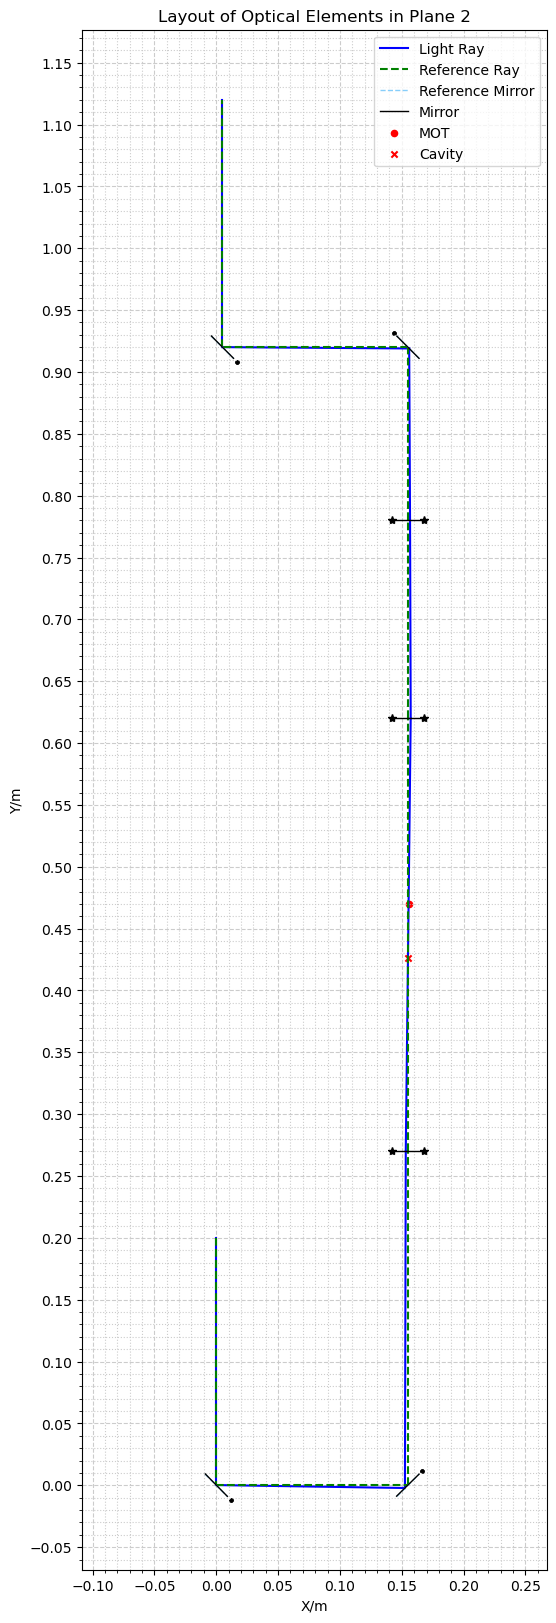

[-365.5675190499583, -424.07156830848237, -51.50726481746401, -168.61335956543218]


100%|██████████| 10/10 [00:14<00:00,  1.40s/it]


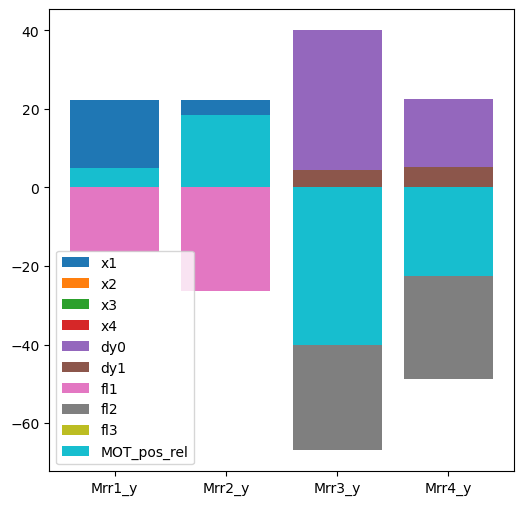

In [4]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.plot_size=(6,20)
solver_0.init_ray_length=0.2
solver_0.xy=1

print('reference')
Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
Mrr_list=[Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y]
knob_deg_list_ref=[]
for Mrr in Mrr_list:
    knob_deg_list_ref.append(Mrr.knob_deg())
fig,ax=plt.subplots(1,1,figsize=(6,6))
print(knob_deg_list_ref)

for i in tqdm(range(len(params_1.keys())-3)):
    params_perturb=params_1.copy()
    params_perturb[list(params_1.keys())[i]]+=0.01
    Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver(params=params_perturb, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
    Mrr_list=[Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y]
    knob_deg_list=[]
    for Mrr in Mrr_list:
        knob_deg_list.append(Mrr.knob_deg())
    ax.bar(['Mrr1_y','Mrr2_y','Mrr3_y','Mrr4_y'],np.array(knob_deg_list)-np.array(knob_deg_list_ref),label=list(params_1.keys())[i])
ax.legend()
plt.show()

reference


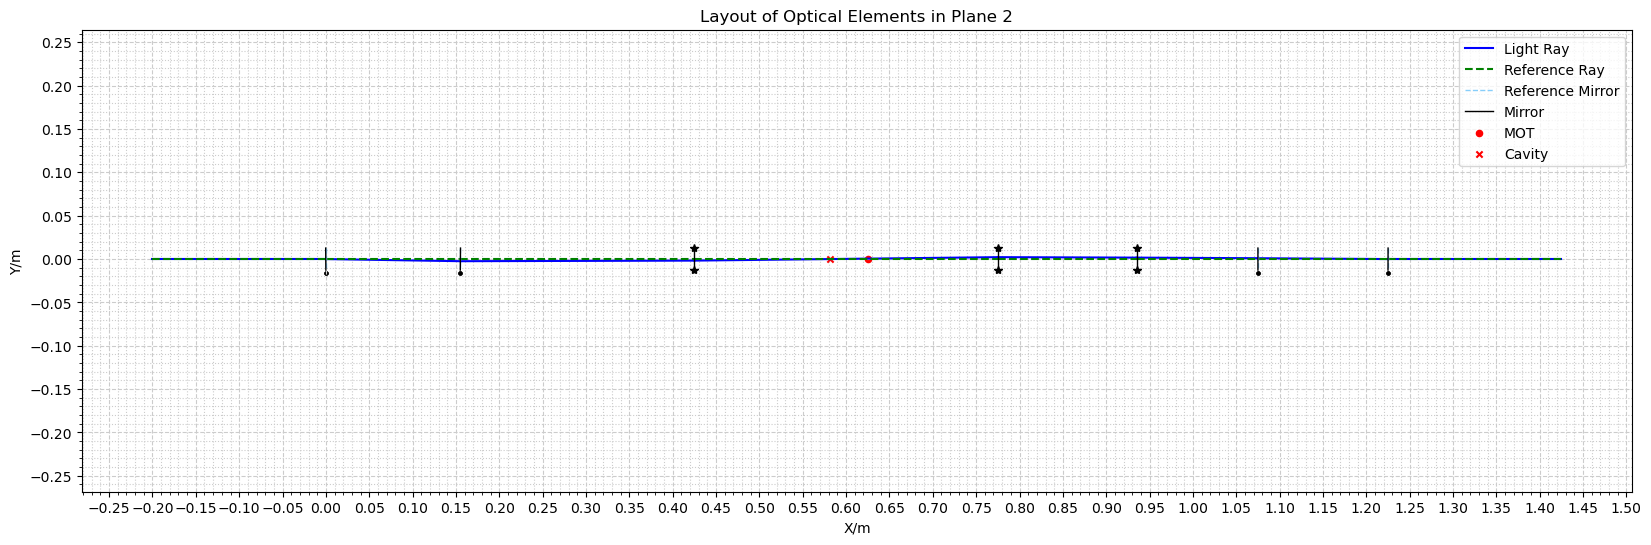

[-368.8412443066162, 427.3453629027319, -34.24553223492426, 151.35143976324915]


100%|██████████| 10/10 [00:50<00:00,  5.05s/it]


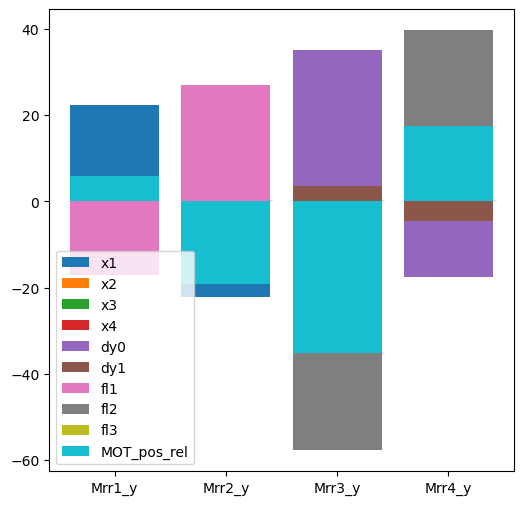

In [5]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.plot_size=(20,6)
solver_0.init_ray_length=0.2
solver_0.xy=1

print('reference')
Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params_2, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
Mrr_list=[Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y]
knob_deg_list_ref=[]
for Mrr in Mrr_list:
    knob_deg_list_ref.append(Mrr.knob_deg())
fig,ax=plt.subplots(1,1,figsize=(6,6))
print(knob_deg_list_ref)

for i in tqdm(range(len(params_2.keys())-3)):
    params_perturb=params_2.copy()
    params_perturb[list(params_2.keys())[i]]+=0.01
    Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params_perturb, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
    Mrr_list=[Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y]
    knob_deg_list=[]
    for Mrr in Mrr_list:
        knob_deg_list.append(Mrr.knob_deg())
    ax.bar(['Mrr1_y','Mrr2_y','Mrr3_y','Mrr4_y'],np.array(knob_deg_list)-np.array(knob_deg_list_ref),label=list(params_2.keys())[i])
ax.legend()
plt.show()

In [3]:
servos.home()
servos.torques_disable()

2025-03-03 17:33:21,076 - INFO - going home


In [8]:
servos.set_zero()

2025-03-03 17:54:06,389 - INFO - Setting Zero
2025-03-03 17:54:06,401 - INFO - Servo 1x: SCServo zero set!
2025-03-03 17:54:06,437 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,472 - INFO - Servo 1y: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,473 - INFO - Servo 1y: SCServo zero set!
2025-03-03 17:54:06,484 - INFO - Servo 2x: SCServo zero set!
2025-03-03 17:54:06,495 - INFO - Servo 2y: SCServo zero set!
2025-03-03 17:54:06,531 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,537 - ERROR - Servo 3x: Read not sucessful!
2025-03-03 17:54:06,573 - INFO - Servo 3x: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,574 - INFO - Servo 3x: SCServo zero set!
2025-03-03 17:54:06,609 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,615 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,621 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,657 - INFO - Servo 3y: result [TxRxResult]

In [ ]:
#servos.set_zero()
servos.torques_disable()

In [29]:
print(MCP3424_fiber.convert_and_read())

1.49


reference


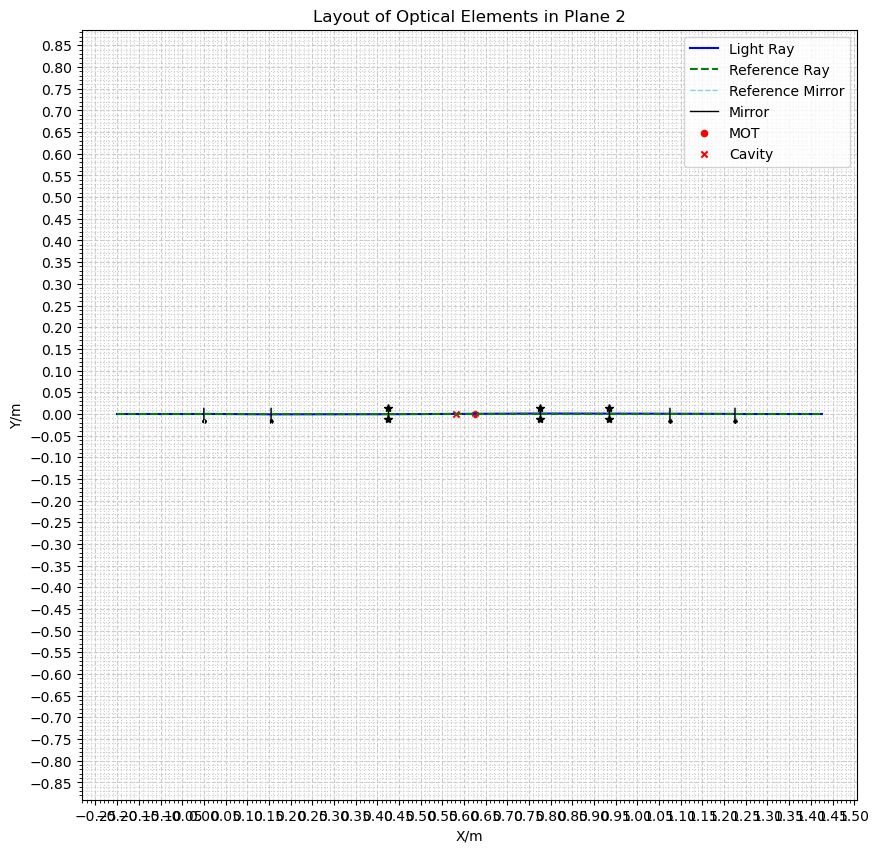

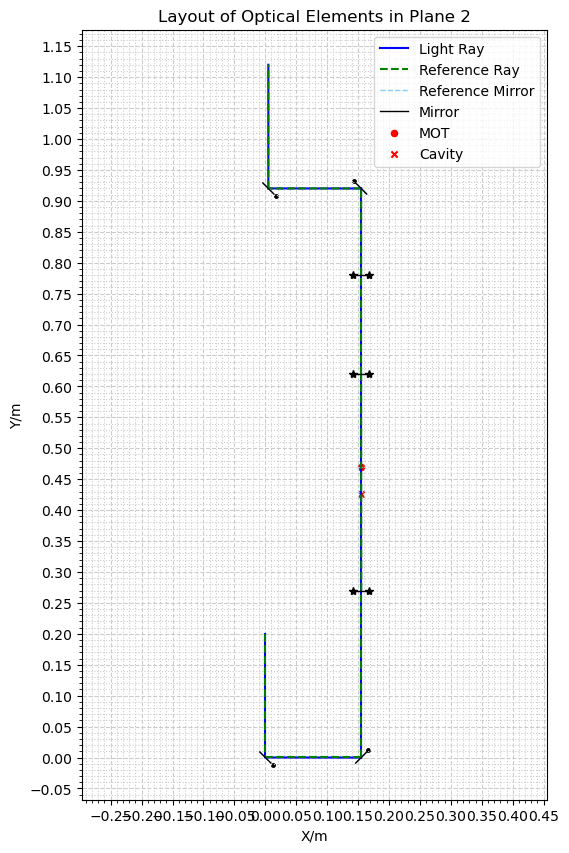

[-147.69734510880116, 171.09760924530318, -13.712233028151207, 60.55474931437654]
[-24.012038290095365, -24.012038290095365, -15.904428833260887, -18.69571803396342]
[24.012038290095365, -147.69734510880116, 24.012038290095365, 171.09760924530318, 15.904428833260887, -13.712233028151207, 18.69571803396342, 60.55474931437654]


In [ ]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2
solver_0.xy=1

print('reference')
Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params_2, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
solver_0.plot_size=(6,10)
Mrr1_x, Mrr2_x, Mrr3_x, Mrr4_x = solver_0.default_setup_solver(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl], plot_switch=1)
print([Mrr1_y.knob_deg(), Mrr2_y.knob_deg(), Mrr3_y.knob_deg(), Mrr4_y.knob_deg()])
print([Mrr1_x.knob_deg(), Mrr2_x.knob_deg(), Mrr3_x.knob_deg(), Mrr4_x.knob_deg()])
knob_deg_list=[Mrr1_x.knob_deg(), Mrr1_y.knob_deg(), Mrr2_x.knob_deg(), Mrr2_y.knob_deg(), Mrr3_x.knob_deg(), Mrr3_y.knob_deg(), Mrr4_x.knob_deg(), Mrr4_y.knob_deg()]
print(knob_deg_list)